In [1]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

(a)

In [2]:
# YPI network
file_path = "CCSB-Y2H.txt"
df = pd.read_csv(file_path, sep="\t", header=None, names=["Protein_A", "Protein_B", "Source"])

G = nx.Graph()
G.add_edges_from(zip(df["Protein_A"], df["Protein_B"]))

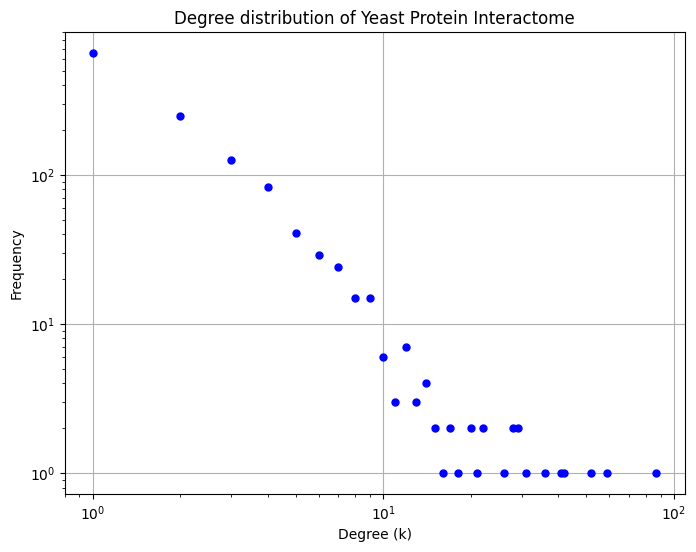

In [3]:
degree_sequence = [d for n, d in G.degree()]
degree_counts = np.bincount(degree_sequence)
degrees = np.nonzero(degree_counts)[0]

# Plot degree distribution
plt.figure(figsize=(8, 6))
plt.loglog(degrees, degree_counts[degrees], 'bo', markersize=5)
plt.xlabel("Degree (k)")
plt.ylabel("Frequency")
plt.title("Degree distribution of Yeast Protein Interactome")
plt.grid(True)
plt.show()

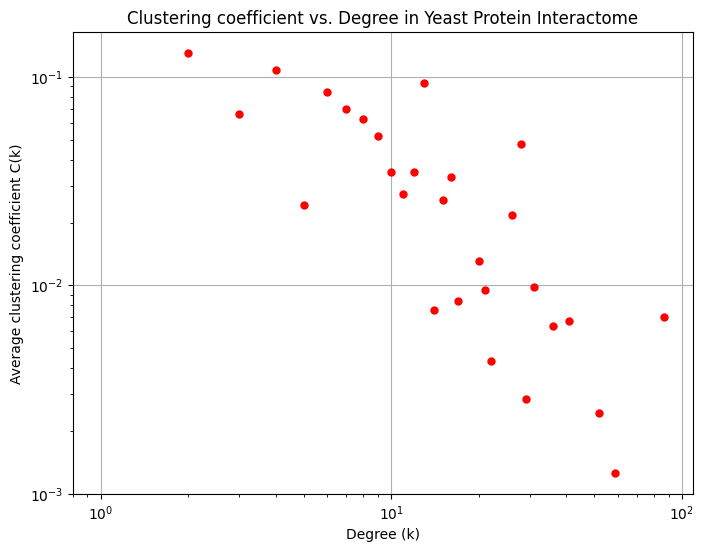

In [4]:
clustering_coeffs = nx.clustering(G)

degree_clustering = {}
for node, degree in dict(G.degree()).items():
    if degree not in degree_clustering:
        degree_clustering[degree] = []
    degree_clustering[degree].append(clustering_coeffs[node])

avg_clustering = {k: np.mean(v) for k, v in degree_clustering.items()}

# Plot C(k) vs k
plt.figure(figsize=(8, 6))
plt.loglog(avg_clustering.keys(), avg_clustering.values(), 'ro', markersize=5)
plt.xlabel("Degree (k)")
plt.ylabel("Average clustering coefficient C(k)")
plt.title("Clustering coefficient vs. Degree in Yeast Protein Interactome")
plt.grid(True)
plt.show()


Network visualized in Cytoscape and visualization saved as CCSB-Y2H.png

Importance of protein in terms of its degree in the Yeast Protein Interactome

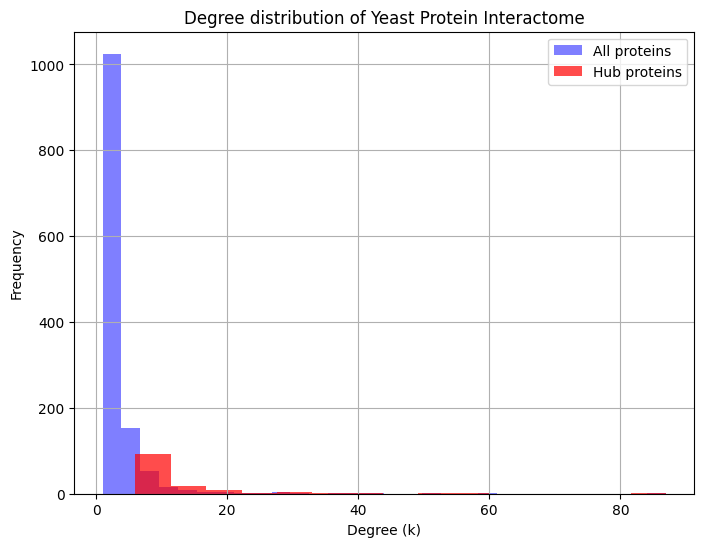

In [10]:
degree_dict = dict(G.degree())
degrees = np.array(list(degree_dict.values()))

# Identify hub proteins
threshold = np.percentile(degrees, 90)
hub_nodes = {node for node, deg in degree_dict.items() if deg >= threshold}

# Plot degree distribution (Hub vs Non-Hub)
plt.figure(figsize=(8, 6))
plt.hist(degrees, bins=30, alpha=0.5, label="All proteins", color="blue")
plt.hist([degree_dict[n] for n in hub_nodes], bins=15, alpha=0.7, label="Hub proteins", color="red")
plt.xlabel("Degree (k)")
plt.ylabel("Frequency")
plt.title("Degree distribution of Yeast Protein Interactome")
plt.legend()
plt.grid(True)
plt.show()

The degree of a protein in the Yeast Protein Interactome (YPI) network represents the number of interactions it has with other proteins. This is crucial because high-degree proteins (hubs) play a significant role in the overall network structure and biological functions

High-degree proteins (hubs) are central to the network, forming the backbone of cellular processes.

If a hub protein is removed (e.g., due to a mutation), the network may collapse, leading to severe functional disruptions.

According to Barabási's "Centrality-Lethality" rule, proteins with higher degrees are more likely to be essential for survival.

In [6]:
import random

(c)

In [7]:
# Compute robustness measures S and <s>
def compute_robustness_measures(graph):
    if len(graph) == 0:
        return 0, 0

    components = [len(c) for c in nx.connected_components(graph)]
    S = max(components) / len(graph)

    smaller_components = [c for c in components if c != max(components)]

    if len(smaller_components) > 0:
        avg_s = np.mean(smaller_components)
    else:
        avg_s = 0

    return S, avg_s

# Random node deletion
def random_node_removal(G, num_steps=100):
    G_rand = G.copy()
    nodes = list(G_rand.nodes())
    random.shuffle(nodes)

    S_list, s_list = [], []
    for i in range(0, len(nodes), len(nodes)//num_steps):
        G_rand.remove_nodes_from(nodes[i:i+len(nodes)//num_steps])
        S, avg_s = compute_robustness_measures(G_rand)
        S_list.append(S)
        s_list.append(avg_s)

    return S_list, s_list

# Targeted node deletion
def targeted_node_removal(G, num_steps=100):
    G_target = G.copy()
    nodes_sorted_by_degree = sorted(G_target.degree(), key=lambda x: x[1], reverse=True)
    nodes = [n[0] for n in nodes_sorted_by_degree]

    S_list, s_list = [], []
    for i in range(0, len(nodes), len(nodes)//num_steps):
        G_target.remove_nodes_from(nodes[i:i+len(nodes)//num_steps])
        S, avg_s = compute_robustness_measures(G_target)
        S_list.append(S)
        s_list.append(avg_s)

    return S_list, s_list

In [8]:
S_random, s_random = random_node_removal(G)
S_targeted, s_targeted = targeted_node_removal(G)

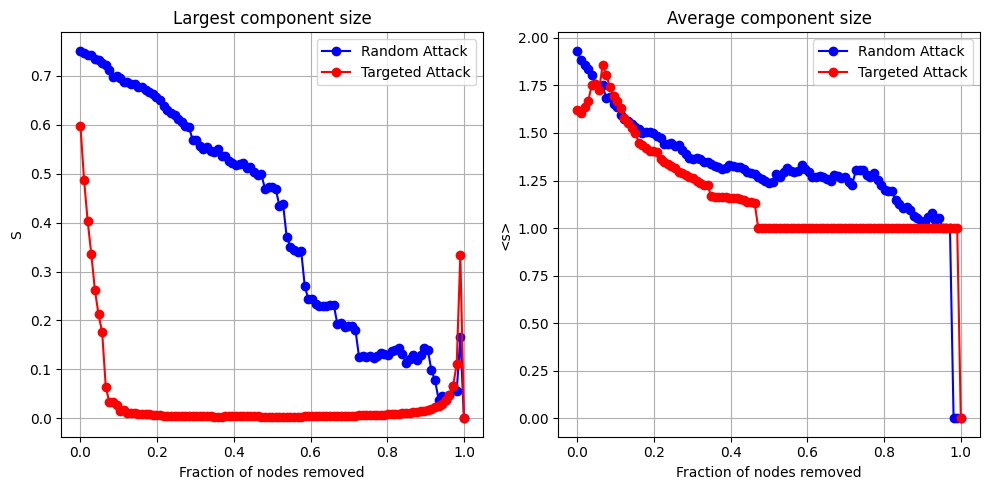

In [9]:
plt.figure(figsize=(10, 5))

# Plot S (Largest component size)
plt.subplot(1, 2, 1)
plt.plot(np.linspace(0, 1, len(S_random)), S_random, 'bo-', label="Random Attack")
plt.plot(np.linspace(0, 1, len(S_targeted)), S_targeted, 'ro-', label="Targeted Attack")
plt.xlabel("Fraction of nodes removed")
plt.ylabel("S")
plt.title("Largest component size")
plt.legend()
plt.grid(True)

# Plot <s> (Average component size excluding largest component)
plt.subplot(1, 2, 2)
plt.plot(np.linspace(0, 1, len(s_random)), s_random, 'bo-', label="Random Attack")
plt.plot(np.linspace(0, 1, len(s_targeted)), s_targeted, 'ro-', label="Targeted Attack")
plt.xlabel("Fraction of nodes removed")
plt.ylabel("<s>")
plt.title("Average component size")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()